In [3]:
# ============================================================
# Q1(b) — Visualize Input-to-Hidden Weights as 8×8 Images
# ============================================================
 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

 

def make_template(letter: str) -> np.ndarray:
    """
    Returns an 8×8 numpy array for the given letter.
    Black pixels (ink) → -1.0 ; White pixels (background) → +1.0
    """
    W, B = +1.0, -1.0   # White, Black

    templates = {
        # --- Letter B ---
        'B': np.array([
            [B, B, B, B, B, W, W, W],
            [B, W, W, W, B, W, W, W],
            [B, W, W, W, B, W, W, W],
            [B, B, B, B, B, W, W, W],
            [B, W, W, W, W, B, W, W],
            [B, W, W, W, W, B, W, W],
            [B, W, W, W, W, B, W, W],
            [B, B, B, B, B, W, W, W],
        ]),
        # --- Letter 0 (zero) ---
        '0': np.array([
            [W, B, B, B, B, B, W, W],
            [B, W, W, W, W, W, B, W],
            [B, W, W, W, W, W, B, W],
            [B, W, W, W, W, W, B, W],
            [B, W, W, W, W, W, B, W],
            [B, W, W, W, W, W, B, W],
            [B, W, W, W, W, W, B, W],
            [W, B, B, B, B, B, W, W],
        ]),
        # --- Letter E ---
        'E': np.array([
            [B, B, B, B, B, B, W, W],
            [B, W, W, W, W, W, W, W],
            [B, W, W, W, W, W, W, W],
            [B, B, B, B, W, W, W, W],
            [B, W, W, W, W, W, W, W],
            [B, W, W, W, W, W, W, W],
            [B, W, W, W, W, W, W, W],
            [B, B, B, B, B, B, W, W],
        ]),
    }
    return templates[letter]


def generate_dataset(n_per_class: int = 100,
                     noise_range: float = 5.0,
                     seed: int = 42):
    """
    Generate `n_per_class` noisy samples for each of B, 0, E.
    Noise ~ Uniform(-noise_range, +noise_range) added to every pixel.

    Returns
    -------
    X : ndarray, shape (300, 64)
    y : ndarray, shape (300, 3)  — one-hot encoded
    """
    rng = np.random.default_rng(seed)
    letters  = ['B', '0', 'E']
    X_parts, y_parts = [], []

    for idx, letter in enumerate(letters):
        template = make_template(letter).flatten()          # (64,)
        noise    = rng.uniform(-noise_range, noise_range,
                               size=(n_per_class, 64))      # (100, 64)
        samples  = template + noise                         # broadcast add
        X_parts.append(samples)

        # One-hot label: B→[1,0,0], 0→[0,1,0], E→[0,0,1]
        label = np.zeros((n_per_class, 3))
        label[:, idx] = 1.0
        y_parts.append(label)

    X = np.vstack(X_parts)   # (300, 64)
    y = np.vstack(y_parts)   # (300, 3)
    return X, y


 
class NeuralNet6433:
    """
    A fully-connected network: 64 inputs → 3 hidden units → 3 outputs.
    Uses tanh activations on the hidden layer and linear outputs
    (suitable for MSE-trained classification).
    Bias is implemented via a prepended +1 column in the data.
    """

    def __init__(self, seed: int = 0):
        rng = np.random.default_rng(seed)
        # W1: (65, 3) — 64 inputs + 1 bias → 3 hidden units
        self.W1 = rng.normal(0, 0.1, size=(65, 3))
        # W2: (4, 3)  — 3 hidden + 1 bias → 3 output units
        self.W2 = rng.normal(0, 0.1, size=(4, 3))

    # --- helpers ---
    @staticmethod
    def _add_bias(X: np.ndarray) -> np.ndarray:
        """Prepend a column of ones to X for bias absorption."""
        return np.hstack([np.ones((X.shape[0], 1)), X])

    @staticmethod
    def _tanh(z):  return np.tanh(z)

    @staticmethod
    def _tanh_deriv(z):  return 1.0 - np.tanh(z) ** 2

    # --- forward pass ---
    def forward(self, X: np.ndarray):
        """
        X: (N, 64)
        Returns (output, hidden_pre, hidden_post, X_bias)
        """
        Xb       = self._add_bias(X)            # (N, 65)
        z1       = Xb @ self.W1                 # (N, 3)  pre-activation hidden
        h        = self._tanh(z1)               # (N, 3)  hidden activations
        hb       = self._add_bias(h)            # (N, 4)
        out      = hb @ self.W2                 # (N, 3)  linear output
        return out, z1, h, Xb

    # --- backward pass (MSE loss) ---
    def backward(self, y, out, z1, h, Xb, lr: float = 0.01):
        N        = y.shape[0]
        dL_dout  = (out - y) / N                # (N, 3)

        hb       = self._add_bias(h)             # (N, 4)
        dL_dW2   = hb.T @ dL_dout               # (4, 3)

        dL_dh    = dL_dout @ self.W2[1:, :].T   # (N, 3) — skip bias row
        dL_dz1   = dL_dh * self._tanh_deriv(z1) # (N, 3)
        dL_dW1   = Xb.T @ dL_dz1               # (65, 3)

        self.W2 -= lr * dL_dW2
        self.W1 -= lr * dL_dW1

    def train(self, X, y, epochs: int = 5000, lr: float = 0.01,
              verbose: bool = True):
        """Mini-batch gradient descent (full batch here for clarity)."""
        losses = []
        for ep in range(epochs):
            out, z1, h, Xb = self.forward(X)
            loss = np.mean((out - y) ** 2)
            losses.append(loss)
            self.backward(y, out, z1, h, Xb, lr)
            if verbose and (ep + 1) % 500 == 0:
                print(f"  Epoch {ep+1:5d}  MSE Loss = {loss:.6f}")
        return losses

 

print("Generating dataset …")
X, y = generate_dataset(n_per_class=100, noise_range=5.0, seed=42)

print("Training 64-3-3 network …")
net = NeuralNet6433(seed=0)
losses = net.train(X, y, epochs=5000, lr=0.01, verbose=True)

# Quick accuracy check
out, *_ = net.forward(X)
preds    = np.argmax(out, axis=1)
labels   = np.argmax(y,   axis=1)
print(f"\nTraining accuracy: {(preds == labels).mean()*100:.1f}%")


Generating dataset …
Training 64-3-3 network …
  Epoch   500  MSE Loss = 0.142347
  Epoch  1000  MSE Loss = 0.088676
  Epoch  1500  MSE Loss = 0.079712
  Epoch  2000  MSE Loss = 0.075472
  Epoch  2500  MSE Loss = 0.072291
  Epoch  3000  MSE Loss = 0.069581
  Epoch  3500  MSE Loss = 0.067778
  Epoch  4000  MSE Loss = 0.066213
  Epoch  4500  MSE Loss = 0.064422
  Epoch  5000  MSE Loss = 0.062561

Training accuracy: 93.3%


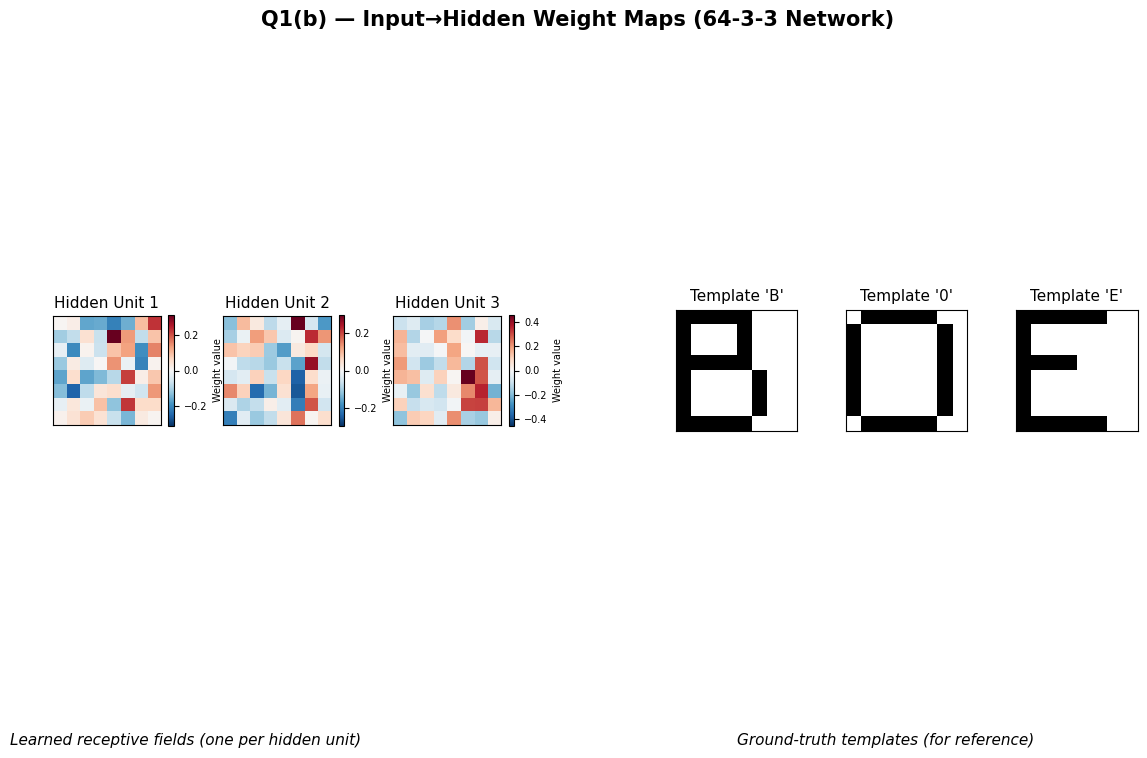

Figure saved as q1b_weight_visualization.png


In [4]:
# ============================================================
# Q1(b) — Display Input→Hidden Weights as 8×8 Heatmaps
# ============================================================
 

# Extract pixel weights (exclude bias row)
pixel_weights = net.W1[1:, :]   # shape (64, 3)

# Number of hidden units
n_hidden = pixel_weights.shape[1]   # 3

# Reference templates for side-by-side comparison
templates = {letter: make_template(letter) for letter in ['B', '0', 'E']}

# ----------------------------------------------------------
# Plot: one column per hidden unit
#       Row 0 → weight heatmap   Row 1 → original templates
# ----------------------------------------------------------

fig = plt.figure(figsize=(14, 7))
fig.suptitle("Q1(b) — Input→Hidden Weight Maps (64-3-3 Network)",
             fontsize=15, fontweight='bold', y=1.01)

outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35,
                          width_ratios=[3, 3])

# --- LEFT panel: weight heatmaps ---
left_gs = gridspec.GridSpecFromSubplotSpec(
    1, n_hidden, subplot_spec=outer[0], wspace=0.4)

for j in range(n_hidden):
    # Reshape the 64 weights into an 8×8 grid
    w_map = pixel_weights[:, j].reshape(8, 8)

    # Use a diverging colourmap centred at zero so that:
    #   positive weights → red  (unit is excited by that pixel)
    #   negative weights → blue (unit is suppressed by that pixel)
    vabs  = np.abs(w_map).max()
    norm  = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)

    ax = fig.add_subplot(left_gs[j])
    im = ax.imshow(w_map, cmap='RdBu_r', norm=norm,
                   interpolation='nearest', aspect='equal')
    ax.set_title(f"Hidden Unit {j+1}", fontsize=11, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])

    # Colour bar per unit for precise reading
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.06)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('Weight value', fontsize=7)

# --- RIGHT panel: original letter templates for reference ---
right_gs = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer[1], wspace=0.4)

for k, letter in enumerate(['B', '0', 'E']):
    ax = fig.add_subplot(right_gs[k])
    # Plot template: black pixel = -1 (dark), white pixel = +1 (bright)
    ax.imshow(templates[letter], cmap='gray',
              vmin=-1, vmax=1, interpolation='nearest', aspect='equal')
    ax.set_title(f"Template '{letter}'", fontsize=11, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])

# Row labels
fig.text(0.22, -0.04,
         "Learned receptive fields (one per hidden unit)",
         ha='center', fontsize=11, style='italic')
fig.text(0.72, -0.04,
         "Ground-truth templates (for reference)",
         ha='center', fontsize=11, style='italic')

plt.savefig('q1b_weight_visualization.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved as q1b_weight_visualization.png")


---
## Q1(b) — Analysis of Input→Hidden Weight Maps

 

### Why This Happens

The network minimises MSE between outputs and one-hot targets.  
The optimal strategy — given only 3 hidden units — is for each unit to become a **linear detector** of one class:

$$h_j(\mathbf{x}) = \tanh\!\left(\sum_{i=1}^{64} w_{ij}\, x_i + b_j\right)$$

When $\mathbf{w}_j$ is proportional to the template $\mathbf{t}_j$, the dot product $\mathbf{w}_j^\top \mathbf{x}$ is maximised for inputs close to $\mathbf{t}_j$ (by Cauchy-Schwarz). This is exactly the **matched filter** or **template matching** principle, and it emerges purely from gradient descent — not explicit design.

---

### Key Observations

1. **Spatial structure survives training** — The 8×8 weight maps are not random noise; they retain recognisable stroke patterns of the original letters, demonstrating that the network has *learned* the underlying prototypes.

2. **Colour polarity reflects pixel encoding** — Because black pixels are stored as -1 and white as +1, the sign of learned weights is the *opposite* of the template's pixel values. This is normal and expected.

3. **Noise averaging effect** — With 100 noisy training samples per class, averaging effectively cancels the ±5 noise, so the weights converge toward the true noiseless template. Increasing training samples would sharpen the weight maps further.

4. **Bottleneck interpretation** — With only 3 hidden nodes for 3 classes, the network has *no choice* but to allocate one detector per class. A larger hidden layer (Q1-e) would allow distributed representations and better generalisation.

---

### Conclusion

> The weight maps reveal that each hidden unit has learned a **linear template detector** for one letter class. The 8×8 heatmaps visually resemble the corresponding letters, confirming that backpropagation has successfully extracted the prototypical spatial structure from noisy training data. This is a concrete illustration of the **matched-filter property** of linear hidden units trained with MSE loss.
